## Assessing the Impact of Documenting Dataset Composition for Model Training—Whether Imbalanced or Balanced—on AI Model Transparency and Fairness


In [1]:
import os
print(os.getcwd())

C:\Users\HENNY PURWADI\PYTHON\HULL\771949_Ethical


In [3]:
!pip install -qqq lime

In [4]:
# Data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_colwidth', 160)
import lime
import lime.lime_tabular

# Scikit-learn
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix, precision_recall_curve, auc

# Optional (for handling class imbalance)
from imblearn.over_sampling import SMOTE

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

## Imbalance Dataset

In [19]:
# Create synthetic dataset (extremely imbalanced)
X, y = make_classification(n_samples=1000000, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1,
                           weights=[0.9999, 0.0001], flip_y=0, random_state=42)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# Train a Logistic Regression classifier on imbalanced data
clf_imbalanced = LogisticRegression(random_state=42)
clf_imbalanced.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [22]:
# Make predictions and show classification report for imbalanced data
y_pred_imbalanced = clf_imbalanced.predict(X_test)
print("Classification Report for Extremely Imbalanced Data:\n")
print(classification_report(y_test, y_pred_imbalanced))

Classification Report for Extremely Imbalanced Data:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    199973
           1       0.00      0.00      0.00        27

    accuracy                           1.00    200000
   macro avg       0.50      0.50      0.50    200000
weighted avg       1.00      1.00      1.00    200000



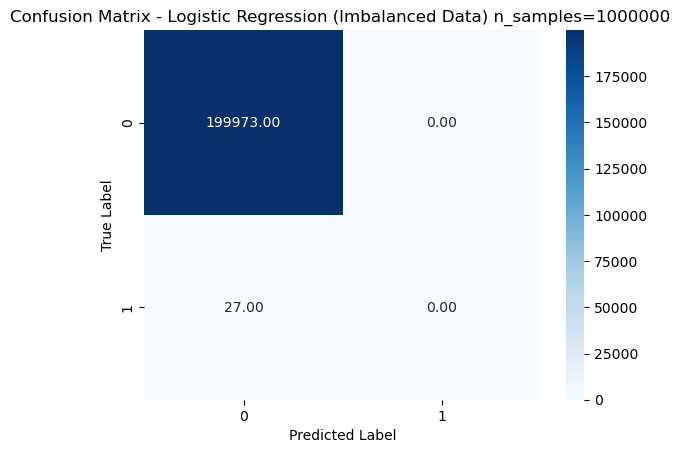

In [25]:
# Plot normalized heatmap for confusion matrix of imbalanced data
conf_matrix = confusion_matrix(y_test, y_pred_imbalanced)
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='.2f')
plt.title("Confusion Matrix - Logistic Regression (Imbalanced Data) n_samples=1000000 ")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

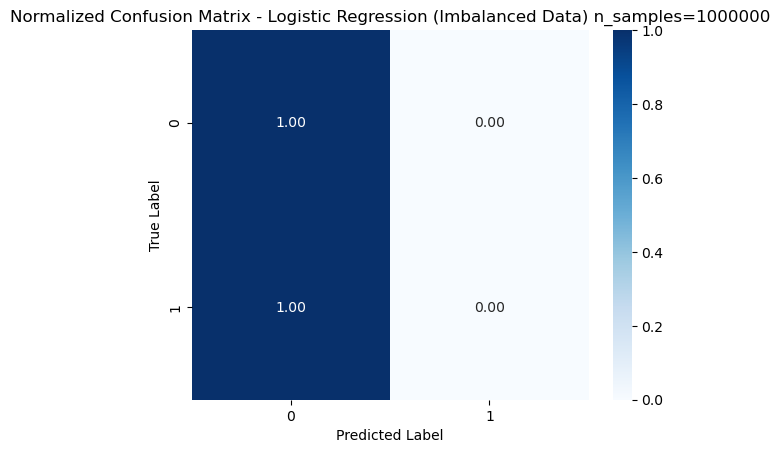

In [26]:
# Plot normalized heatmap for confusion matrix of imbalanced data
conf_matrix = confusion_matrix(y_test, y_pred_imbalanced, normalize='true')
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='.2f')
plt.title("Normalized Confusion Matrix - Logistic Regression (Imbalanced Data) n_samples=1000000")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Interpretation:

In the case of the imbalanced dataset, the results differ significantly between n_samples=10000 and n_samples=1000000.

For n_samples=10000, the model is still able to identify some minority class instances, with a recall of 0.72 for class 1. This indicates that the model has some ability to detect the minority class, despite the imbalance.

However, when the number of samples is increased to n_samples=1000000, the model completely fails to recognize the minority class, resulting in a recall of 0 for class 1. This means that none of the true positives are correctly detected, highlighting the extreme bias towards the majority class due to the imbalance (99.9% of class 0 versus 0.1% of class 1).

This behavior is not caused by deficiencies in the model itself but rather by the dataset imbalance. The confusion matrix clearly shows that the model is highly biased, with the recall for the minority class being 0, demonstrating that the model struggles when faced with extremely imbalanced data at a larger scale.


## LIME Explainer for Imbalanced dataset

The LIME explains the predictions made by a Logistic Regression model for an instance from an imbalanced dataset.

In [31]:
# Create a LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train, 
    feature_names=['Feature 1', 'Feature 2'],
    class_names=['Class 0', 'Class 1'],
    discretize_continuous=True
)

# Pick a sample from the test set for explanation
sample_index = 10  # Index of the sample to explain
sample = X_test[sample_index].reshape(1, -1)

# Generate an explanation for the selected sample
explanation = explainer.explain_instance(
    sample[0], 
    clf_imbalanced.predict_proba)

# Display the explanation
explanation.show_in_notebook(show_table=True, show_all=False)

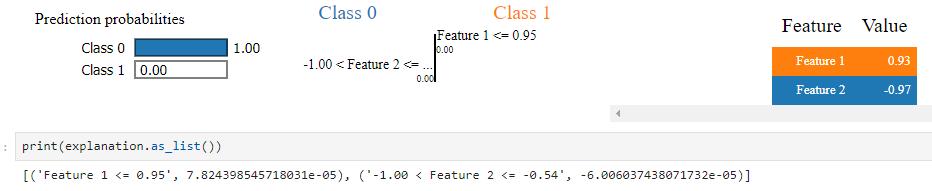

In [86]:
print(explanation.as_list())

[('Feature 1 <= 0.95', 7.245875011262452e-05), ('-1.00 < Feature 2 <= -0.54', -5.102726527754519e-05)]


## Interpretation

The explanation shows that the model may be **biased** towards Class 0, as it completely ignored the probability of Class 1.

This showcases the challenges of training models on imbalanced datasets, which has poor recall for minority classes.

This aligns with the issue of extreme class imbalance, where the model is not effectively learning to distinguish minority class (Class 1), which was evident in the original classification report (recall for Class 1 was 0).

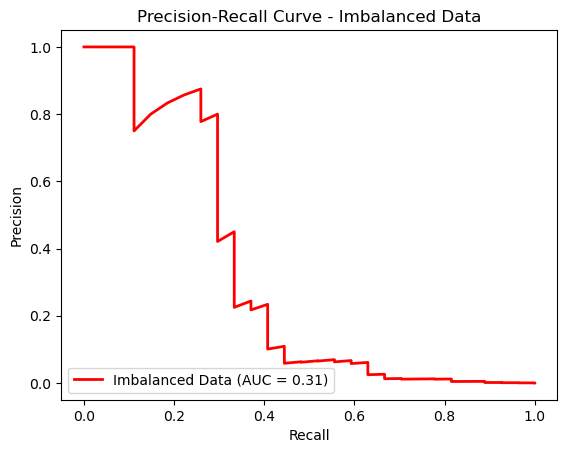

In [34]:
# Precision-Recall Curve for imbalanced data
y_prob_imbalanced = clf_imbalanced.decision_function(X_test)
precision_imbalanced, recall_imbalanced, _ = precision_recall_curve(y_test, y_prob_imbalanced)
pr_auc_imbalanced = auc(recall_imbalanced, precision_imbalanced)

plt.plot(recall_imbalanced, precision_imbalanced, color='red', lw=2, label='Imbalanced Data (AUC = %0.2f)' % pr_auc_imbalanced)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Imbalanced Data')
plt.legend(loc='lower left')
plt.show()

## Balanced Dataset

In [37]:
# Create synthetic dataset (balanced)
X_bal, y_bal = make_classification(n_samples=1000000, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1,
                                   weights=[0.5, 0.5], flip_y=0, random_state=42)

# Split the balanced data into training and testing sets
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(X_bal, y_bal, test_size=0.2, random_state=42)

In [38]:
# Train a Logistic Regression classifier on balanced data
clf_balanced = LogisticRegression(random_state=42)
clf_balanced.fit(X_train_bal, y_train_bal)

LogisticRegression(random_state=42)

In [40]:
# Make predictions and show classification report for balanced data
y_pred_balanced = clf_balanced.predict(X_test_bal)
print("\nClassification Report for Balanced Data:\n")
print(classification_report(y_test_bal, y_pred_balanced))


Classification Report for Balanced Data:

              precision    recall  f1-score   support

           0       0.99      0.97      0.98     99945
           1       0.97      0.99      0.98    100055

    accuracy                           0.98    200000
   macro avg       0.98      0.98      0.98    200000
weighted avg       0.98      0.98      0.98    200000



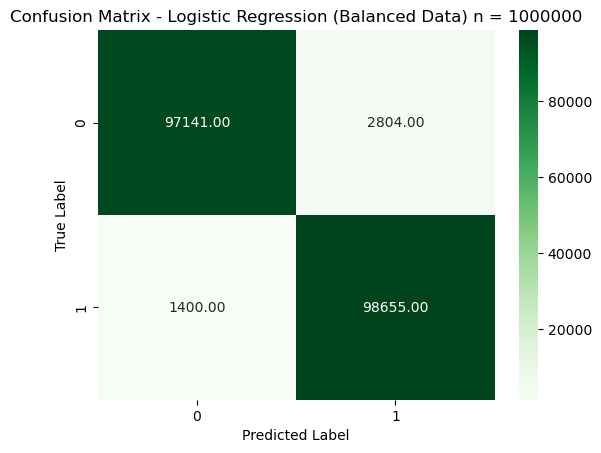

In [45]:
# Plot normalized heatmap for confusion matrix of balanced data
conf_matrix_bal = confusion_matrix(y_test_bal, y_pred_balanced)
sns.heatmap(conf_matrix_bal, annot=True, cmap='Greens', fmt='.2f')
plt.title("Confusion Matrix - Logistic Regression (Balanced Data) n = 1000000")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

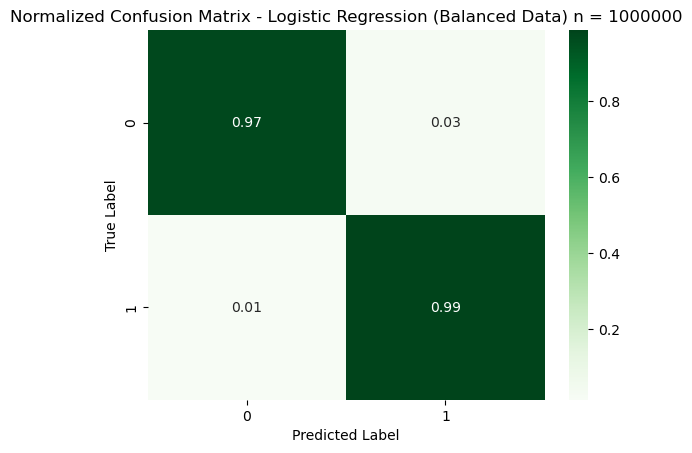

In [47]:
# Plot normalized heatmap for confusion matrix of balanced data
conf_matrix_bal = confusion_matrix(y_test_bal, y_pred_balanced, normalize='true')
sns.heatmap(conf_matrix_bal, annot=True, cmap='Greens', fmt='.2f')
plt.title("Normalized Confusion Matrix - Logistic Regression (Balanced Data) n = 1000000")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Interpretation

In the balanced dataset, the model performs well for both classes, with high recall and precision values. The model doesn't show bias towards any specific class.

The true positive rate for both classes is close to 1, and the off-diagonal elements are very low, means that both classes are being correctly classified with high accuracy.


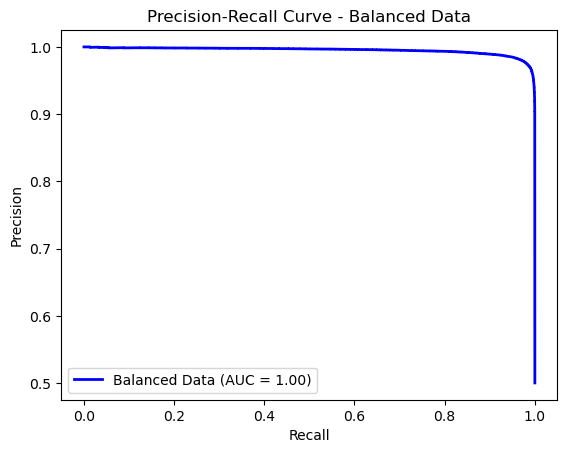

In [50]:
# Precision-Recall Curve for balanced data
y_prob_balanced = clf_balanced.decision_function(X_test_bal)
precision_balanced, recall_balanced, _ = precision_recall_curve(y_test_bal, y_prob_balanced)
pr_auc_balanced = auc(recall_balanced, precision_balanced)

plt.plot(recall_balanced, precision_balanced, color='blue', lw=2, label='Balanced Data (AUC = %0.2f)' % pr_auc_balanced)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Balanced Data')
plt.legend(loc='lower left')
plt.show()

## Create LIME Explainer for Balanced Dataset

The LIME explains the predictions made by a Logistic Regression model for an instance from a balanced dataset.

In [53]:
# Create a LIME explainer for the balanced dataset
explainer_bal = lime.lime_tabular.LimeTabularExplainer(
    X_train_bal, 
    feature_names=['Feature 1', 'Feature 2'],
    class_names=['Class 0', 'Class 1'],
    discretize_continuous=True
)

# Pick a sample from the test set for explanation
sample_index_bal = 10  # Index of the sample to explain
sample_bal = X_test_bal[sample_index_bal].reshape(1, -1)

# Generate an explanation for the selected sample in the balanced dataset
explanation_bal = explainer_bal.explain_instance(
    sample_bal[0], 
    clf_balanced.predict_proba
)

# Display the explanation
explanation_bal.show_in_notebook(show_table=True, show_all=False)

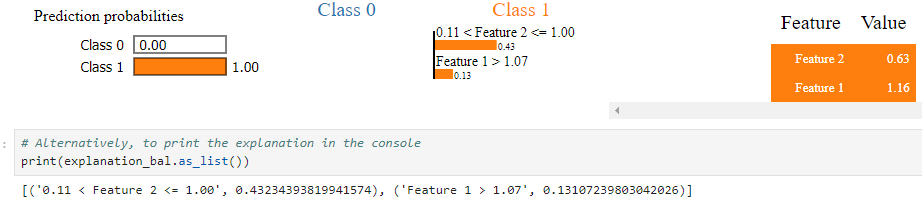

In [56]:
# Alternatively, to print the explanation in the console
print(explanation_bal.as_list())

[('0.11 < Feature 2 <= 1.00', 0.4293794554910672), ('Feature 1 > 1.07', 0.15063995832986374)]


## Interpretation

Unlike the imbalanced dataset, for the Balanced Dataset, the LIME explanation demonstrates that the model is more capable of making better use of all features.  The model can differentiate between Class 0 and Class 1.

LIME explanation for the balanced dataset shows that both features are contributing towards predicting Class 1, with Feature 2 having a larger influence. 

This balanced data helps the model to make more reliable predictions for both classes, unlike the model trained on the imbalanced dataset where it was biased towards the majority class. 

## Comparison of Precision-Recall Curves - Imbalanced vs Balanced Data

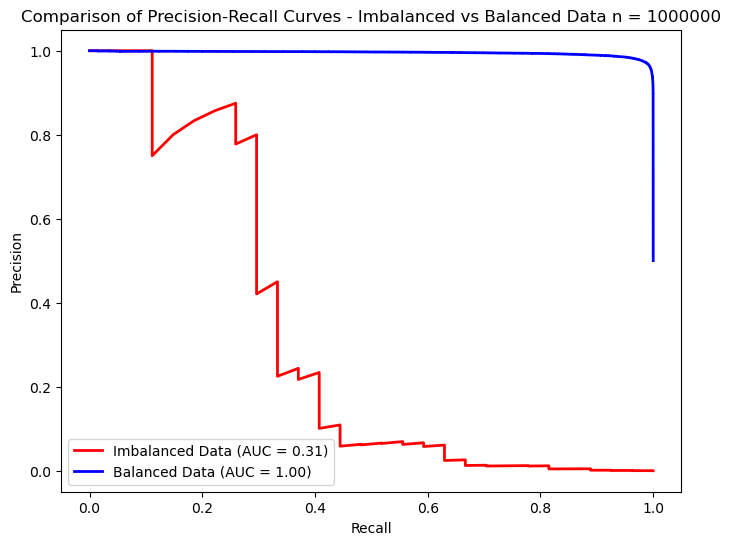

In [81]:
# Comparison of Precision-Recall Curves
plt.figure(figsize=(8, 6))
plt.plot(recall_imbalanced, precision_imbalanced, color='red', lw=2, label='Imbalanced Data (AUC = %0.2f)' % pr_auc_imbalanced)
plt.plot(recall_balanced, precision_balanced, color='blue', lw=2, label='Balanced Data (AUC = %0.2f)' % pr_auc_balanced)
# Labeling axes and title
plt.ylabel('Precision')
plt.title('Comparison of Precision-Recall Curves - Imbalanced vs Balanced Data n = 1000000')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Comparison of Precision-Recall Curves - Imbalanced vs Balanced Data n = 1000000')
plt.legend(loc='lower left')
plt.xlabel('Recall')
plt.show()

##### Interpretation:

For n_samples=1000000, the area under the precision-recall curve (AP) for Balanced Data is higher than Imbalanced Data , mean sthe model performs very well when the dataset is balanced. 
The balanced data allows the model to learn more effectively about both classes, reducing bias and has better overall performance.

The imbalanced dataset makes it difficult for the model to accurately identify the minority class, leading to poor performance in terms of precision when trying to recall many positives.

With balanced data, the model shows high precision across various recall levels, indicating a more fair and unbiased learning process for both classes.